## 08. Modeliranje: Eksperiment D (MC + embeddings + DL)

U ovom notebook-u treniramo MLP (multi-layer perceptron) nad Multi-Class (MC) podskupom proteina, koristeći ESM-2 embeddinge kao ulazne feature. Prati istu strukturu kao notebook 06 (SC + DL), ali prilagođenu multi-label klasifikaciji. 

Koristimo isti MC train/test split i isti MultiLabelBinarizer definisan u notebook-u u 03, čime osiguravamo fer poređenje sa klasičnim modelima iz notebook-a 07.

### Uvoz biblioteka

In [2]:
import os
import json
import joblib
import copy
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import(f1_score, hamming_loss, accuracy_score, classification_report)

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Koristi se uredjaj: {DEVICE}")

Koristi se uredjaj: cpu


### Konfiguracija i putanje

In [3]:
DATA_DIR = "../../data/processed/localization"
FEATURES_DIR = "../../data/features/localization"
MODELS_DIR = "../../data/models/localization"
METRICS_DIR = "../../results/metrics/localization"
FIGURES_DIR = "../../results/figures/localization"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

### Učitavanje podataka

In [4]:
# Koristimo isti MC train/test split i isti MultiLabelBinarizer definisani u notebook-u 03 
# - fer poređenje klasicnog ML i DL pristupa

# Entry liste za MC train/test skup (03 notebook)
entries_mc_train = pd.read_csv(os.path.join(FEATURES_DIR, "mc_train_entries.csv"))["Entry"].values
entries_mc_test = pd.read_csv(os.path.join(FEATURES_DIR, "mc_test_entries.csv"))["Entry"].values

# MultiLabelBinarizer fit-ovan jednom u 03
mlb = joblib.load(os.path.join(FEATURES_DIR, "mc_label_binarizer.pkl"))
label_columns = list(mlb.classes_)
NUM_CLASSES = len(label_columns)

# Labels
mc_labels_df = pd.read_csv(os.path.join(FEATURES_DIR, "mc_labels.csv"), index_col="Entry")

y_mc_train = mc_labels_df.loc[entries_mc_train, label_columns].values.astype(np.float32)
y_mc_test = mc_labels_df.loc[entries_mc_test, label_columns].values.astype(np.float32)

print(f"Train skup: {len(entries_mc_train)} proteina")
print(f"Test skup:  {len(entries_mc_test)} proteina")
print(f"Klase: {label_columns}")
print(f"y_mc_train: {y_mc_train.shape} | y_mc_test: {y_mc_test.shape}")

Train skup: 11708 proteina
Test skup:  2858 proteina
Klase: ['Cell membrane', 'Cytoplasm', 'Mitochondrion', 'Nucleus', 'Secreted']
y_mc_train: (11708, 5) | y_mc_test: (2858, 5)


In [5]:
# ESM2 embeddinzi (izracunati u 05)
MODEL_TAG = "t12_35M"
embeddings_df = pd.read_csv(os.path.join(FEATURES_DIR, F"esm2_embeddings_{MODEL_TAG}.csv"), index_col="Entry")

X_mc_train = embeddings_df.loc[entries_mc_train].values.astype(np.float32)
X_mc_test = embeddings_df.loc[entries_mc_test].values.astype(np.float32)

EMBEDDING_DIM = X_mc_train.shape[1]

print(f"Dimenzija embeddinga: {EMBEDDING_DIM}")
print(f"X_mc_train: {X_mc_train.shape} | X_mc_test: {X_mc_test.shape}")

Dimenzija embeddinga: 480
X_mc_train: (11708, 480) | X_mc_test: (2858, 480)


### Validacioni split

In [6]:
# Stratifikacija po broju labela po proteinu
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=RANDOM_STATE
)

train_idx, val_idx  = next(msss.split(X_mc_train, y_mc_train))

X_tr, X_val = X_mc_train[train_idx], X_mc_train[val_idx]
y_tr, y_val = y_mc_train[train_idx], y_mc_train[val_idx]

print(f"Trening podskup:    {X_tr.shape[0]} proteina")
print(f"Validacioni podskup: {X_val.shape[0]} proteina")

Trening podskup:    9938 proteina
Validacioni podskup: 1770 proteina


In [7]:
# Provjera da li je stratifikacija uspjesna
print("Train label proportions:")
print(y_tr.mean(axis=0))

print("\nValidation label proportions:")
print(y_val.mean(axis=0))

Train label proportions:
[0.28063998 0.3979674  0.09327833 0.39233246 0.14550212]

Validation label proportions:
[0.2779661  0.3943503  0.09265537 0.38926554 0.1440678 ]


### Skaliranje embeddinga

Standardizacija (fitovana isključivo na trening podskupu) ubrzava konvergenciju.

In [8]:
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_mc_test)

joblib.dump(scaler, os.path.join(MODELS_DIR, "mc_dl_embedding_scaler.pkl"))

['../../data/models/localization\\mc_dl_embedding_scaler.pkl']

### PyTorch Dataset i DataLoader

In [9]:
class ProteinEmbeddingMultiLabelDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_dataset = ProteinEmbeddingMultiLabelDataset(X_tr_scaled, y_tr)
val_dataset = ProteinEmbeddingMultiLabelDataset(X_val_scaled, y_val)
test_dataset = ProteinEmbeddingMultiLabelDataset(X_test_scaled, y_mc_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Balansiranje klasa

Kod multi-label klasifikacije koristimo pos_weight parametar BCEWithLogitsLoss-a, koji za svaku klasu skalira gubitak pozitivnih primjera prema omjeru negativnih/pozitivnih primjera u trening skupu (analogno class_weight="balanced" iz notebook-a 07).

In [19]:
n_pos = y_tr.sum(axis=0)
n_neg = y_tr.shape[0] - n_pos
# odnos pozitivnih i negativnih
pos_weight = n_neg / np.clip(n_pos, 1, None)
# NumPy niz pretvaramo u PyTorch tensor i saljemo na GPU/CPU
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(DEVICE)

for cls, w in zip(label_columns, pos_weight):
     print(f" {cls:<20} -> {w:.3f}")

 Cell membrane        -> 2.563
 Cytoplasm            -> 1.513
 Mitochondrion        -> 9.721
 Nucleus              -> 1.549
 Secreted             -> 5.873


### Hiperparametarska pretraga za MLP

Analogno GridSearchCV pristupu iz notebook-a 07, radimo grubu pretragu male mreže hiperparametara (hidden_dims, dropout) za MLP arhitekturu. 

In [12]:
import itertools

# Funkcija za izgradnju modela
def build_model(input_dim, num_classes, hidden_dims, dropout):
    layers = []
    prev_dim = input_dim
    for h in hidden_dims:
        layers.extend([
            nn.Linear(prev_dim, h),
            nn.BatchNorm1d(h),
            nn.ReLU(),
            nn.Dropout(dropout)
        ])
        prev_dim = h
    layers.append(nn.Linear(prev_dim, num_classes))
    return nn.Sequential(*layers)

#### Trening modela sa early stopping-om

In [20]:
def train_one_config(hidden_dims, dropout, lr, weight_decay, 
                     train_loader, val_loader, pos_weight_tensor,
                     input_dim, num_classes, max_epochs=100, patience=15):
    
    torch.manual_seed(RANDOM_STATE)
    model = build_model(input_dim, num_classes, hidden_dims, dropout).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)

    best_val_f1 = -1.0
    epochs_no_improve = 0
    best_model_state = None

    history = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(1, max_epochs + 1):
        # Trening
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        # Prosjecni loss za cijeli trening skup
        train_loss = running_loss / len(train_dataset)

        # Validacija
        model.eval()
        all_preds, all_targets = [], []
        val_loss_sum = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss_sum += loss.item() * X_batch.size(0)

                preds = (torch.sigmoid(outputs) >= 0.5).float()
                all_preds.append(preds.cpu().numpy())
                all_targets.append(y_batch.cpu().numpy())

        val_loss = val_loss_sum / len(val_loader.dataset)
        val_f1 = f1_score(np.vstack(all_targets), np.vstack(all_preds), average="micro", zero_division=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        scheduler.step(val_f1)

        print(
            f"Epoha {epoch:3d} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val F1: {val_f1:.4f}"
        )

        # Early stopping po val F1 micro (primarni kriterijum), val_loss samo za monitoring
        if val_f1 > best_val_f1 + 1e-4:
            best_val_f1 = val_f1
            best_val_loss_at_best = val_loss
            epochs_no_improve = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    print()
    model.load_state_dict(best_model_state)
    return model, best_val_f1, best_val_loss_at_best, history, epoch

#### Mreža hiperparametara

In [21]:
# Gruba mreža hiperparametara 
hidden_dims_options = [(256, 128), (128, 64)]
dropout_options = [0.3, 0.5]
lr_options = [1e-3]
weight_decay_options = [1e-4]

search_results = []
best_overall = {"val_f1": -1.0}

# Treniranja - sve kombinacije
for hidden_dims, dropout, lr, wd in itertools.product(
    hidden_dims_options, dropout_options, lr_options, weight_decay_options
):
    print(f"Treniranje: hidden_dims={hidden_dims}, dropout={dropout}, lr={lr}, wd={wd}")

    model, val_f1, val_loss, history, n_epochs = train_one_config(
        hidden_dims, dropout, lr, wd,
        train_loader, val_loader, pos_weight_tensor,
        EMBEDDING_DIM, NUM_CLASSES
    )

    search_results.append({
        "hidden_dims": hidden_dims, "dropout": dropout, "lr": lr, "weight_decay": wd,
        "val_f1_micro": val_f1, "val_loss": val_loss, "epochs": n_epochs
    })

    if val_f1 > best_overall["val_f1"]:
        best_overall = {"val_f1": val_f1, "model": model, "history": history, "config": (hidden_dims, dropout, lr, wd)}

search_df = pd.DataFrame(search_results).sort_values("val_f1_micro", ascending=False)
print(search_df)

# Najbolja konfiguracija
model = best_overall["model"]
history = best_overall["history"]
print(f"\nNajbolja konfiguracija: {best_overall['config']} | Val F1 micro: {best_overall['val_f1']:.4f}")

Treniranje: hidden_dims=(256, 128), dropout=0.3, lr=0.001, wd=0.0001
Epoha   1 | Train loss: 0.6043 | Val loss: 0.5405 | Val F1: 0.7245
Epoha   2 | Train loss: 0.5329 | Val loss: 0.5296 | Val F1: 0.7398
Epoha   3 | Train loss: 0.5052 | Val loss: 0.5182 | Val F1: 0.7448
Epoha   4 | Train loss: 0.4923 | Val loss: 0.5174 | Val F1: 0.7475
Epoha   5 | Train loss: 0.4771 | Val loss: 0.5283 | Val F1: 0.7556
Epoha   6 | Train loss: 0.4647 | Val loss: 0.5171 | Val F1: 0.7526
Epoha   7 | Train loss: 0.4576 | Val loss: 0.5268 | Val F1: 0.7492
Epoha   8 | Train loss: 0.4462 | Val loss: 0.5198 | Val F1: 0.7605
Epoha   9 | Train loss: 0.4395 | Val loss: 0.5274 | Val F1: 0.7564
Epoha  10 | Train loss: 0.4324 | Val loss: 0.5339 | Val F1: 0.7517
Epoha  11 | Train loss: 0.4296 | Val loss: 0.5335 | Val F1: 0.7516
Epoha  12 | Train loss: 0.4197 | Val loss: 0.5314 | Val F1: 0.7498
Epoha  13 | Train loss: 0.4129 | Val loss: 0.5439 | Val F1: 0.7506
Epoha  14 | Train loss: 0.4046 | Val loss: 0.5584 | Val F1: 

### Vizualizacija toka treninga

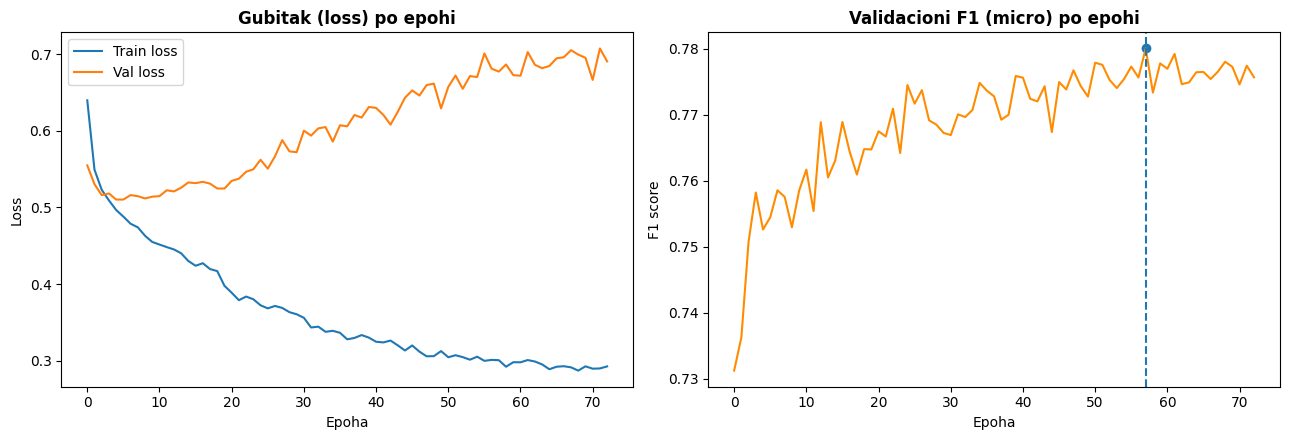

In [22]:
best_epoch = np.argmax(history["val_f1"]) + 1
best_f1 = max(history["val_f1"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history["train_loss"], label="Train loss")
axes[0].plot(history["val_loss"], label="Val loss")
axes[0].set_title("Gubitak (loss) po epohi", fontweight="bold")
axes[0].set_xlabel("Epoha")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["val_f1"], label="Val F1 (micro)", color="darkorange")
axes[1].axvline(best_epoch - 1, linestyle="--", label=f"Najbolji F1 (epoha {best_epoch})")

axes[1].scatter(best_epoch - 1, best_f1)
axes[1].set_title("Validacioni F1 (micro) po epohi", fontweight="bold")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("F1 score")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_dl_mc_training_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

### Per-class threshold optimizacija

In [23]:
def find_best_thresholds(model, val_loader, num_classes, thresholds=np.arange(0.1, 0.91, 0.05)):
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            probs = torch.sigmoid(model(X_batch))
            all_probs.append(probs.cpu().numpy())
            all_targets.append(y_batch.numpy())

    all_probs = np.vstack(all_probs)
    all_targets = np.vstack(all_targets)

    best_thresholds = np.full(num_classes, 0.5)
    for c in range(num_classes):
        best_f1_c = -1.0
        for t in thresholds:
            preds_c = (all_probs[:, c] >= t).astype(float)
            f1_c = f1_score(all_targets[:, c], preds_c, zero_division=0)
            if f1_c > best_f1_c:
                best_f1_c = f1_c
                best_thresholds[c] = t
    return best_thresholds

best_thresholds = find_best_thresholds(model, val_loader, NUM_CLASSES)

for cls, t in zip(label_columns, best_thresholds):
    print(f" {cls:<20} -> prag: {t:.2f}")

 Cell membrane        -> prag: 0.60
 Cytoplasm            -> prag: 0.50
 Mitochondrion        -> prag: 0.85
 Nucleus              -> prag: 0.50
 Secreted             -> prag: 0.85


### Evaluacija na test skupu

Koristimo iste metrike kao u notebook-u 07 (F1 micro/macro/samples, Hamming loss, subset accuracy) radi direktnog poređenja klasičnih i DL modela.
python

In [24]:
def evaluate(model, loader, thresholds):
    model.eval()
    all_preds, all_targets = [], []
    thresholds_t = torch.tensor(thresholds, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            outputs = model(X_batch)
            probs = torch.sigmoid(outputs)
            preds = (probs >= thresholds_t).float()
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.numpy())
    return np.vstack(all_targets), np.vstack(all_preds)

# Poređenje: fiksni prag 0.5 vs. optimizovani pragovi
y_test_true, y_test_pred_default = evaluate(model, test_loader, np.full(NUM_CLASSES, 0.5))
y_test_true, y_test_pred_opt = evaluate(model, test_loader, best_thresholds)

f1_default = f1_score(y_test_true, y_test_pred_default, average="micro", zero_division=0)
f1_opt = f1_score(y_test_true, y_test_pred_opt, average="micro", zero_division=0)

print(f"Test F1 micro (prag=0.5):        {f1_default:.3f}")
print(f"Test F1 micro (per-class pragovi): {f1_opt:.3f}")

Test F1 micro (prag=0.5):        0.782
Test F1 micro (per-class pragovi): 0.796


In [25]:
y_train_true, y_train_pred_opt = evaluate(model, DataLoader(train_dataset, batch_size=BATCH_SIZE), best_thresholds)

train_f1_micro = f1_score(y_train_true, y_train_pred_opt, average="micro", zero_division=0)
train_f1_macro = f1_score(y_train_true, y_train_pred_opt, average="macro", zero_division=0)
train_acc = accuracy_score(y_train_true, y_train_pred_opt)

test_f1_micro = f1_score(y_test_true, y_test_pred_opt, average="micro", zero_division=0)
test_f1_macro = f1_score(y_test_true, y_test_pred_opt, average="macro", zero_division=0)
test_f1_samples = f1_score(y_test_true, y_test_pred_opt, average="samples", zero_division=0)
test_acc = accuracy_score(y_test_true, y_test_pred_opt)
test_hamming = hamming_loss(y_test_true, y_test_pred_opt)

print(f"Train F1 micro: {train_f1_micro:.3f} | Train Subset Accuracy: {train_acc:.3f}")
print(f"Test F1 micro:  {test_f1_micro:.3f} | Test F1 macro: {test_f1_macro:.3f} | Test F1 samples: {test_f1_samples:.3f}")
print(f"Test Subset Accuracy: {test_acc:.3f} | Test Hamming Loss: {test_hamming:.3f}")
print(f"Overfit Gap (F1 micro): {train_f1_micro - test_f1_micro:.3f}")
print()
print(classification_report(y_test_true, y_test_pred_opt, target_names=label_columns, zero_division=0))


Train F1 micro: 0.877 | Train Subset Accuracy: 0.717
Test F1 micro:  0.796 | Test F1 macro: 0.784 | Test F1 samples: 0.812
Test Subset Accuracy: 0.594 | Test Hamming Loss: 0.110
Overfit Gap (F1 micro): 0.081

               precision    recall  f1-score   support

Cell membrane       0.86      0.79      0.82       820
    Cytoplasm       0.75      0.84      0.79      1164
Mitochondrion       0.73      0.61      0.67       273
      Nucleus       0.79      0.80      0.79      1147
     Secreted       0.87      0.81      0.84       426

    micro avg       0.79      0.80      0.80      3830
    macro avg       0.80      0.77      0.78      3830
 weighted avg       0.80      0.80      0.80      3830
  samples avg       0.83      0.85      0.81      3830



### Čuvanje rezultata i modela

In [26]:
best_hidden_dims, best_dropout, best_lr, best_wd = best_overall["config"]

dl_mc_results = {
    "Model": "MLP (PyTorch)",
    "Feature set": "ESM-2 embeddings",

    "Hidden dims": str(best_hidden_dims),
    "Dropout": best_dropout,
    "Learning rate": best_lr,
    "Weight decay": best_wd,

    "Train F1 micro": train_f1_micro,
    "Train F1 macro": train_f1_macro,
    "Train Subset Accuracy": train_acc,

    "Test F1 micro": test_f1_micro,
    "Test F1 macro": test_f1_macro,
    "Test F1 samples": test_f1_samples,
    "Test Subset Accuracy": test_acc,
    "Test Hamming Loss": test_hamming,

    "Overfit Gap (F1 micro)": train_f1_micro - test_f1_micro,
    
    "Best val F1 micro": best_overall["val_f1"],
    "Best epoch": len(best_overall["history"]["val_f1"]),
}

# Cuvanje rezultata eksperimenta
dl_mc_results_df = pd.DataFrame([dl_mc_results])
dl_mc_results_df.to_csv(os.path.join(METRICS_DIR, "mc_dl_modeling_results.csv"), index=False)

# Cuvanje naucenih weights modela
torch.save(model.state_dict(), os.path.join(MODELS_DIR, "mc_dl_mlp_esm2.pt"))

# Cuvanje tabele hiperparametarske pretrage
search_df.to_csv(os.path.join(METRICS_DIR, "mc_dl_hyperparam_search.csv"), index=False)

with open(os.path.join(MODELS_DIR, "mc_dl_mlp_config.json"), "w") as f:
    json.dump({
        "input_dim": EMBEDDING_DIM,
        "num_classes": NUM_CLASSES,
        "hidden_dims": list(best_hidden_dims),
        "dropout": best_dropout,
        "learning_rate": best_lr,
        "weight_decay": best_wd,
        "thresholds": best_thresholds.tolist(),
        "label_columns": label_columns,
    }, f, indent=2)

print("Rezultati i model sacuvani.")
dl_mc_results_df

Rezultati i model sacuvani.


,Model,Feature set,Hidden dims,Dropout,Learning rate,Weight decay,Train F1 micro,Train F1 macro,Train Subset Accuracy,Test F1 micro,Test F1 macro,Test F1 samples,Test Subset Accuracy,Test Hamming Loss,Overfit Gap (F1 micro),Best val F1 micro,Best epoch
0,MLP (PyTorch),ESM-2 embeddings,"(128, 64)",0.3,0.001,0.0001,0.877344,0.898817,0.716844,0.796202,0.783799,0.812141,0.593772,0.109657,0.081141,0.78002,73
